In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path('..').resolve()
SCRIPTS_DIR  = PROJECT_ROOT / 'scripts'
DATA_PATH    = PROJECT_ROOT / 'data' / 'single-cell-tracks_exp1-6_noErbB2.csv'
META_PATH    = PROJECT_ROOT / 'data' / '01-readme-experiment-description_2022-04-05.csv'
OUTPUT_PATH = PROJECT_ROOT / 'analysis_outputs'
EXP_ID = 1
SIGNAL_COL = 'ERKKTR_ratio'
MAX_TAU = 6

### Generacja Grafu

Wybraliśmy PIK3CA_H1047R i PIK3CA_E545K, ponieważ chcieliśmy zobaczyć jak bardzo 2 mutacje zlokalizowane w jednym genie (które dodatkowo drastycznie inaczej wpływają na poziom ryzyka, co wykazaliśmy w zadaniu A1) są podobne lub jak bardzo się różnią.

In [3]:
MUTANT_SITES = {
    "WT": 1,
    "PIK3CA_E545K": 9,
    "PIK3CA_H1047R": 13
}

In [41]:
import subprocess
import sys

processes = []

for site_id in MUTANT_SITES.values():
    print(f"Starting analysis for site {site_id}...")
    cmd = [
        sys.executable,
        str(SCRIPTS_DIR / 'spatiotemporal_signal_propagation.py'),
        '--data-path', str(DATA_PATH),
        '--meta-path', str(META_PATH),
        '--exp-id', str(EXP_ID),
        '--site-id', str(site_id),
        '--output-dir', str(OUTPUT_PATH),
    ]
    p = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
    processes.append((site_id, p))

for site_id, p in processes:
    stdout, stderr = p.communicate()
    print(f"--- Output for site {site_id} ---")
    print(stdout)
    if p.returncode != 0:
        print(f"Error for site {site_id}:\n", stderr)

Starting analysis for site 1...
Starting analysis for site 9...
Starting analysis for site 13...
--- Output for site 1 ---

Spatiotemporal graph analysis complete.
Output directory: /home/Latrynator/Desktop/biologia_systemuf/projekt_2/Systems-Biology_project-2/Part_A/analysis_outputs/exp_1_site_1_ERKKTR_ratio
Mutation: WT
Nodes: 356,632
Spatial edges: 2,389,504
Temporal edges: 354,834
Jump threshold on ERKKTR_ratio: 0.0365
Interpretation of "jump": a large upward change since the previous frame.
Neighbour jump now means: at least one nearby cell shows such a large upward change at the current frame.
Future self jump means: the same cell shows such a large upward change within the next 3 frames.
Future jump rate with neighbour jump now: 0.13145546310189607
Future jump rate without neighbour jump now: 0.07486715044854579
Risk difference: 0.05658831265335028 (absolute probability gap; 0.05 means 5 percentage points higher).
Relative risk: 1.7558496926130764 (times more likely; 1 means no 

### Obliczenie RR

In [1]:
#  tworzenie funkcji aby wywołać analizę dla każdego tau

def compute_RR(mutant: str, max_lag: int):

    nodes = pd.read_csv(OUTPUT_PATH / f"exp_{EXP_ID}_site_{MUTANT_SITES[mutant]}_{SIGNAL_COL}" / 'nodes.csv.gz')
    nodes = nodes.sort_values(['track_id', 'Image_Metadata_T']).reset_index(drop=True)

    for tau in range(1, max_lag + 1):
    # shift(tau) within each track: row at position i gets the value from i-tau
    # i.e. "neighbour jump status tau frames ago"
        nodes[f'lagged_exposure_{tau}'] = (
            nodes.groupby('track_id')['neighbor_jump_now']
                .shift(tau)
                .fillna(False)
                .astype(bool)
    )
    

    results = []

    for tau in range(max_lag + 1):
        col = 'neighbor_jump_now' if tau == 0 else f'lagged_exposure_{tau}'
        exposed   = nodes[nodes[col] == True]
        unexposed = nodes[nodes[col] == False]

        p_exp   = exposed['future_self_jump'].mean()
        p_unexp = unexposed['future_self_jump'].mean()
        rr = p_exp / p_unexp if p_unexp > 0 else np.nan
        rd = p_exp - p_unexp

        results.append({
            'τ (frames)': tau,
            'τ (min)':    tau * 5,
            'n_exposed':  len(exposed),
            'p_exp':      round(p_exp, 4),
            'p_unexp':    round(p_unexp, 4),
            'RD':         round(rd, 4),
            'RR':         round(rr, 4),
        })

    df_lag = pd.DataFrame(results)
    return df_lag


In [5]:
# obliczenie i zapisanie wyników dla każdego mutanta do słownika

RR_per_mutant = {mutant: compute_RR(mutant, MAX_TAU) for mutant in MUTANT_SITES}

In [6]:
# tworzenie dataframe z wynikami dla wszystkich mutantów
df = pd.concat(RR_per_mutant)
df = df.reset_index()
df = df.rename(columns={df.columns[0]: "Mutant"})
df["Mutant"] = df["Mutant"].replace("", np.nan)
df["Mutant"] = df["Mutant"].ffill()

df

,Mutant,level_1,τ (frames),τ (min),n_exposed,p_exp,p_unexp,RD,RR
0,WT,0,0,0,146620,0.1315,0.0749,0.0566,1.7558
1,WT,1,1,5,145714,0.1284,0.0772,0.0513,1.6640
2,WT,2,2,10,144813,0.1248,0.0799,0.0450,1.5627
3,WT,3,3,15,143980,0.1206,0.0829,0.0377,1.4549
4,WT,4,4,20,143194,0.1169,0.0856,0.0313,1.3661
5,WT,5,5,25,142405,0.1136,0.0878,0.0258,1.2940
6,WT,6,6,30,141705,0.1108,0.0898,0.0210,1.2337
7,PIK3CA_E545K,0,0,0,126377,0.1399,0.0860,0.0539,1.6264
8,PIK3CA_E545K,1,1,5,125612,0.1349,0.0894,0.0455,1.5096
9,PIK3CA_E545K,2,2,10,125011,0.1291,0.0931,0.0359,1.3859


In [65]:
# zapisanie df do pilku .csv
import os
os.makedirs(PROJECT_ROOT / 'A_2' / 'task_outputs', exist_ok=True)
df.to_csv(PROJECT_ROOT / 'A_2' / 'task_outputs' / 'lagged_exposure_table.csv')

### Tabelka podsumowująca


In [71]:
idx = df.groupby('Mutant')['RR'].idxmax()
result = df.loc[idx, ['Mutant', 'τ (frames)', 'τ (min)', 'RR']]

result

,Mutant,τ (frames),τ (min),RR
7,PIK3CA_E545K,0,0,1.6264
14,PIK3CA_H1047R,0,0,2.8435
0,WT,0,0,1.7558


### Wizualizacja

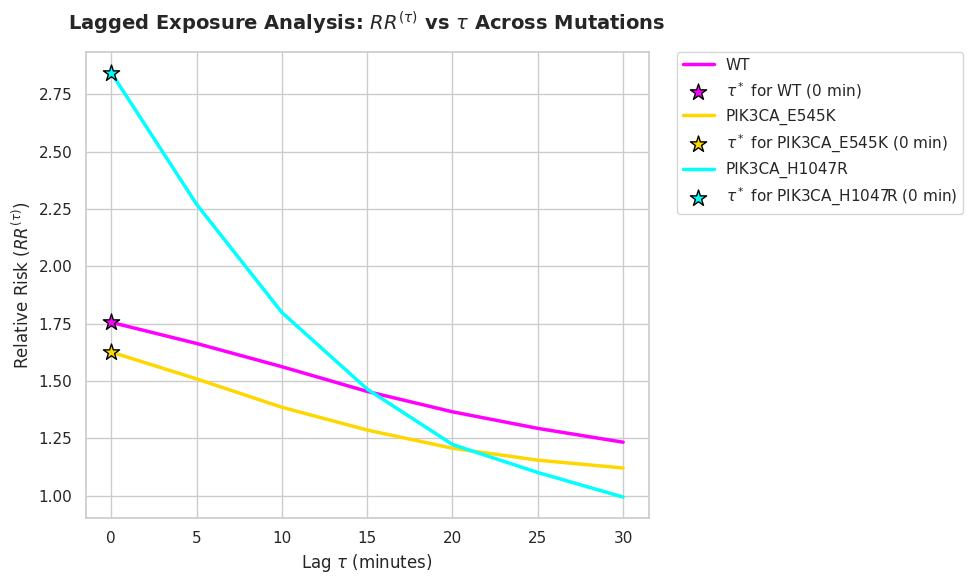

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# układ ślicznych kolorów :)
colors = {"WT": "magenta", "PIK3CA_E545K": "gold", "PIK3CA_H1047R": "cyan"}


for mutant in df["Mutant"].unique():
    
    sub_df = df[df["Mutant"] == mutant].sort_values(by="τ (min)")

    # linia trendu RR vs τ (min)
    plt.plot(
        sub_df["τ (min)"],
        sub_df["RR"],
        label=mutant,
        color=colors[mutant],
        linewidth=2.5,
    )

    # znajdujemy punkt τ*, gdzie RR osiąga maksimum
    idx_max = sub_df["RR"].idxmax()
    tau_star = sub_df.loc[idx_max, "τ (min)"]
    max_rr = sub_df.loc[idx_max, "RR"]

    # dodajemy wyraźny marker w punkcie (τ*, max_RR)
    plt.scatter(
        tau_star,
        max_rr,
        color=colors[mutant],
        s=150,
        zorder=5,
        marker="*",
        edgecolors="black",
        label=f"$\\tau^*$ for {mutant} ({tau_star} min)",
    )


plt.title(
    "Lagged Exposure Analysis: $RR^{(\\tau)}$ vs $\\tau$ Across Mutations",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Lag $\\tau$ (minutes)", fontsize=12)
plt.ylabel("Relative Risk ($RR^{(\\tau)}$)", fontsize=12)

# Ustawiamy dokładne wartości na osi X, które masz w danych
plt.xticks(df["τ (min)"].unique())

# Wyświetlamy legendę poza wykresem lub w optymalnym miejscu
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0.0)

plt.savefig(PROJECT_ROOT / 'A_2' / 'task_outputs' / 'lagged_exposure_plot.png', bbox_inches='tight', dpi=300)

plt.tight_layout()
plt.show()

In [ ]:
# zapis wykresu

plt.savefig(PROJECT_ROOT / 'A_2' / 'task_outputs' / 'lagged_exposure_plot.png', dpi=300, bbox_inches='tight')

### Interpretacja

Celem analizy było zobrazowanie różnic między 2 mutacjami w 1 genie, oraz prędkości rozpowszechniania się sygnału pośród komórek.

Jak widać na wykresie maksymalne RR osiągane jest dla wszystkich mutantów w chwili t=0. Z czasem metryka ta spada.


1) Mutant "PKI3CA_H1047R" wykazuje silną hiperaktywację oraz znacznie bardziej drastyczny spadek RR z czasem w porównaniu do "WT" i "PIK3CA_E545K".
Można to zjawisko wytłumaczyć wzmożonym działaniem regulacji w ramach komórki typu "sprzężenie zwrotne ujemne"

2) Wariant dziki "WT" oraz mutant "PIK3CA_E545K" cechcują się bardzo podobną krzywą zmiany RR, z taką różnicą że wariant dziki na ogół ma wyższe wartości.